# Lecture 11: Creating a Neural Network

## Activity 1: Creating Neurons

In [1]:
inputs = [1.3, 2.4,3.6, -1.8]
weights1 = [0.2, 0.8, -0.5, 0.3]
weights2 = [0.5, -0.84, 0.53, -0.3]
weights3 =[-0.21,-0.62, 0.16,0.78]

bias1 = 2
bias2 = 4
bias3 = 0.8
        # Neuron 1
output =(inputs[0]*weights1[0]+inputs[1]*weights1[1]+inputs[2]*weights1[2]+inputs[3]*weights1[3]+bias1,

        # Neuron 2
        inputs[0]*weights2[0]+inputs[1]*weights2[1]+inputs[2]*weights2[2]+inputs[3]*weights2[3]+bias2,

        # Neuron 3
        inputs[0]*weights3[0]+inputs[1]*weights3[1]+inputs[2]*weights3[2]+inputs[3]*weights3[3]+bias3)

print(output)


(1.8399999999999996, 5.082, -1.7890000000000004)


## Activity 2: Neuron Lessons with Numpy

In [2]:
# Example Creating a Single Neuron
import numpy as np

inputs =[3.0, 2.6, 1.7, 2.1]
weights= [0.1, -2.3, 0.8, -1.3]
bias = 2.1

outputs = np.dot(weights, inputs) + bias
print(outputs)

-4.949999999999999


In [3]:
# Layer of Neurons
import numpy as np

weights= [0.1, -2.3, 0.8, -1.3]

# Define inputs as a list of lists, representing a 2D array

inputs = [
    [3.0, 2.6, 1.7, 2.1],
    [0.4, 0.2, -0.33, -0.22],
    [-0.77, -0.54, -0.23, 0.7]
]
bias = [2.0, 1.1, 0.5]

# Perform matrix multiplication using np.dot
outputs = np.dot(inputs, weights) + bias # Switched order of inputs and weights

print(outputs)

[-5.05   0.702  0.571]


## Activity 3:  Batches

In [4]:
# Batch
import numpy as np

inputs = [
    [3.0, 2.6, 1.7, 2.1],
    [0.4, 0.2, -0.33, -0.22],
    [-0.77, -0.54, -0.23, 0.7]
]
weights = [
    [0.1, -2.3, 0.8, -1.3],
    [0.5, -0.84, 0.53, -0.3],
    [-0.21, -0.62, 0.16, 0.78]
]
bias = [2.0, 1.1, 0.5]

# Perform matrix multiplication using np.dot
outputs = np.dot(inputs, np.array(weights).T) + bias # Transpose weights for correct multiplication

print(outputs)

[[-5.05    0.687   0.168 ]
 [ 1.602   1.0231  0.0676]
 [ 2.071   0.8367  1.5057]]


## Activity 4: Layers

In [5]:
import numpy as np

# Input Layer
inputs = [
    [5, 6, 7, 9],
    [1, 2, 3, 4],
    [6, 1, 7, 1]
]

# Layer 1
weights1 = [
    [7, 2, 1, 8],
    [2, 5, 3, 5],
    [1, 8, 7, 4]
]
biases = [2, 5, 3]

# Layer 2
weights2 = [
    [7, 2, 1],
    [2, 5, 3],
    [1, 8, 7]
]
biases2 = [-3, 0.5, 2]

layer1_outputs = np.dot(inputs, np.array(weights1).T) + biases
layer2_outputs = np.dot(layer1_outputs, np.array(weights2).T) + biases2

print("Layer 1 Outputs:")
print(layer1_outputs)
print("\nLayer 2 Outputs:")
print(layer2_outputs)



Layer 1 Outputs:
[[128 111 141]
 [ 48  46  57]
 [ 61  48  70]]

Layer 2 Outputs:
[[1256.  1234.5 2005. ]
 [ 482.   497.5  817. ]
 [ 590.   572.5  937. ]]


# Lecture 10: Introduction to Artificial Intelligence and Neural Network

In [13]:
# Step 1: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

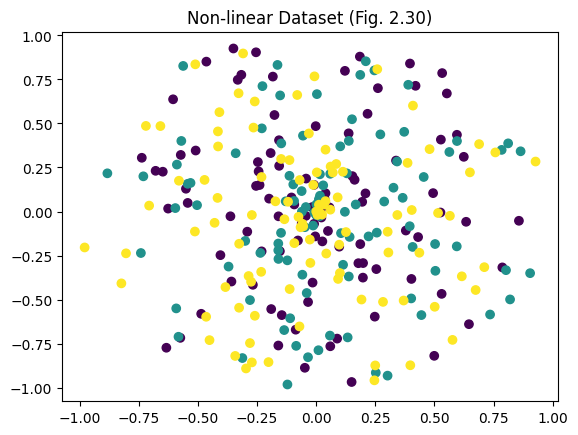

In [14]:
# Step 2: Create synthetic dataset
def scatter_data(points, classes):
    X = np.zeros((points * classes, 2))
    y = np.zeros(points * classes)
    for class_number in range(classes):
        ix = range(points * class_number, points * (class_number + 1))
        r = np.linspace(0.0, 1, points)
        t = np.linspace(class_number * 4, (class_number + 1) * 5, points) + np.random.randn(points) * 3
        
        X[ix] = np.c_[r * np.sin(t * 3.0), r * np.cos(t * 3.0)]
        y[ix] = class_number
    return X, y

# Visualize the dataset
X, y = scatter_data(100, 3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title("Non-linear Dataset (Fig. 2.30)")
plt.show()

In [15]:
# Step 3: Define a Layer class
class Layers:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.12 * np.random.rand(n_inputs, n_neurons)
        self.bias = np.zeros((1, n_neurons))
    
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.bias

In [16]:
# Step 4: Define the ReLU activation function
class ReLU:
    def __init__(self):
        pass

    def forward(self, inputs):
        self.output = np.maximum(0, inputs)

In [17]:
# Step 5: Create layer and activation objects
layer1 = Layers(n_inputs=2, n_neurons=4) # You can change number of neurons
activation1 = ReLU()

In [18]:
# Step 6: Forward pass without ReLU
layer1.forward(X)
print("Output before ReLU:")
print(layer1.output)

Output before ReLU:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-4.28771302e-04 -7.29234526e-05 -6.56849366e-04 -2.82054516e-04]
 [ 1.29547461e-03  2.29980263e-03  8.20703453e-04  4.91834531e-04]
 ...
 [ 4.09507017e-02  6.02427996e-03  6.32601307e-02  2.71011756e-02]
 [-6.01360825e-02 -3.94736253e-02 -7.57556009e-02 -3.44906684e-02]
 [-5.27116632e-02 -1.07116701e-01 -2.58154272e-02 -1.76659499e-02]]


In [19]:
# Step 7: Apply ReLU activation
activation1.forward(layer1.output)
print("Output after ReLU:")
print(activation1.output)

Output after ReLU:
[[0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.00129547 0.0022998  0.0008207  0.00049183]
 ...
 [0.0409507  0.00602428 0.06326013 0.02710118]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]
